# 헬스케어 보험료 데이터 EDA — 과제 해답

**목표** : 무엇이 보험료(`charges`)를 결정하는지 찾고, 예측 모델을 제안한다

---

## 0. 준비

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
sns.set_style('whitegrid')

import warnings
warnings.filterwarnings('ignore')

In [2]:
# 폰트 설정
from matplotlib import font_manager

for _f in ['Malgun Gothic', 'AppleGothic', 'NanumGothic']:
    if _f in {f.name for f in font_manager.fontManager.ttflist}:
        plt.rcParams['font.family'] = _f
        break
else:
    print('[경고] 한글 폰트 없음 — 그래프 한글이 □ 로 보일 수 있습니다')

plt.rcParams['axes.unicode_minus'] = False   # 음수 부호 깨짐 방지

In [3]:
# 데이터 불러오기 (경로 확인 !)
original = pd.read_csv('insurance.csv')
df = original.copy()

print('데이터 크기:', df.shape)
df.head()

데이터 크기: (1338, 7)


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


---

# 1. 데이터 이해 및 준비

## 1-1. 각 컬럼의 의미 정리

In [4]:
# 컬럼별 타입과 결측 여부를 한 번에 확인
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [10]:
print('charges 기초 통계')
print(f"최솟값 {df['charges'].min():,.0f} ~ 최댓값 {df['charges'].max():,.0f}")
print(f"평균   {df['charges'].mean():,.0f}")
print(f"중앙값 {df['charges'].median():,.0f}")

charges 기초 통계
최솟값 1,122 ~ 최댓값 63,770
평균   13,270
중앙값 9,382


### 컬럼 설명

| 컬럼 | 의미 | 유형 | 값의 범위 |
|---|---|---|---|
| `age` | 피보험자 나이 | 수치형-연속 | 18 ~ 64세 |
| `sex` | 성별 | 범주형-명목 | `female` / `male` |
| `bmi` | 체질량지수 (몸무게 kg ÷ 키 m²) | 수치형-연속 | 약 16 ~ 53 |
| `children` | 부양 자녀 수 | 수치형-이산 | 0 ~ 5명 |
| `smoker` | 흡연 여부 | 범주형-이진 | `yes` / `no` |
| `region` | 거주 지역 (미국 4개 권역) | 범주형-명목 | northeast / northwest / southeast / southwest |
| **`charges`** | **개인 의료비 청구액 — 타깃** | 수치형-연속 | 약 1,122 ~ 63,770 |

### ★ `charges`에 대하여

**보험사가 해당 가입자에게 청구한(또는 지급한) 개인 의료비**입니다.
단위는 달러이며, **연 단위 개인별 총액**으로 이해하면 됩니다.

성격을 세 가지로 정리하면:

1. **연속형 수치**이며 **항상 양수**입니다.
2. **오른쪽으로 치우쳐 있습니다** - 평균이 중앙값보다 훨씬 큽니다  
   대다수는 적게 쓰고 소수가 아주 많이 쓰는 **의료비 특유의 분포**입니다
3. 최댓값이 최솟값의 **50배가 넘습니다** - 개인 간 격차가 매우 큽니다

In [ ]:
# 결측치와 중복 확인 — 분석 전 반드시 하는 점검
print('결측치 개수')
print(df.isnull().sum())
print()
print(f'중복 행: {df.duplicated().sum()}건')

# 중복이 있다면 실제로 확인해 본다
if df.duplicated().sum() > 0:
    print()
    print('중복된 행:')
    print(df[df.duplicated(keep=False)])

# 결측치는 없지만, 중복인 행이 하나 있음.
# 다른 사람인데 조건이 동일한 사람일 가능성이 있으니 그대로 둔다. (특정인 식별 불가능하기 때문)

결측치 개수
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

중복 행: 1건

중복된 행:
     age   sex    bmi  children smoker     region    charges
195   19  male  30.59         0     no  northwest  1639.5631
581   19  male  30.59         0     no  northwest  1639.5631


## 1-2. 확인해보고 싶은 정보 (가설)

보험료를 결정하는 요인을 찾는 것이 목표이므로, 가설도 그 방향으로 세웁니다.

| # | 가설 | 근거 | 확인 방법 |
|---|---|---|---|
| H1 | **흡연자의 보험료가 훨씬 높을 것이다** | 흡연은 대표적 건강 위험 요인 | 그룹별 평균 비교 (6번 항목) |
| H2 | **나이가 많을수록 보험료가 높을 것이다** | 의료 이용이 나이에 비례 | 산점도 · 상관계수 (4·5번) |
| H3 | **BMI 가 높을수록 보험료가 높을 것이다** | 비만은 만성질환 위험 요인 | 산점도 (4번) |
| H4 | 자녀 수가 많으면 보험료가 높을 것이다 | 가족 단위 의료 이용 증가 | 상관계수 (5번) |
| H5 | 지역에 따라 보험료가 다를 것이다 | 지역별 의료 수가 차이 | 그룹별 분포 (3번) |
| H6 | 성별에 따라 보험료가 다를 것이다 | — | 그룹별 비교 (6번) |

---

# 2. 기본 통계량 및 데이터 구조

## 2-1. 수치형 변수의 기본 통계량

In [ ]:
# 수치형 변수의 기술통계량
df.describe().round(2)

,age,bmi,children,charges
count,1338.00,1338.00,1338.00,1338.00
mean,39.21,30.66,1.09,13270.42
std,14.05,6.10,1.21,12110.01
min,18.00,15.96,0.00,1121.87
25%,27.00,26.30,0.00,4740.29
50%,39.00,30.40,1.00,9382.03
75%,51.00,34.69,2.00,16639.91
max,64.00,53.13,5.00,63770.43


In [ ]:
# charges의 왜도
df.charges.skew()

np.float64(1.5158796580240388)

### 해석

| 변수 | 평균 | 중앙값 | 읽는 법 |
|---|---|---|---|
| `age` | 약 39세 | 39세 | **거의 같다** → 나이 분포는 대칭적 |
| `bmi` | 약 30.7 | 30.4 | **거의 같다** → BMI 도 대칭에 가깝다 |
| `children` | 약 1.1명 | 1명 | 0명이 가장 많은 이산형 |
| **`charges`** | **약 13,270** | **약 9,382** | **평균이 중앙값의 1.4배** → 크게 치우침 |

**`charges` 만 평균과 중앙값이 크게 벌어집니다.**  
왜도가 1.5 로 다른 변수들(0에 가까움)과 확연히 다릅니다.

> **보고할 때는 중앙값을 함께 적어야 합니다.**  
> x "평균 보험료는 13,270 입니다"  
> o "보험료 중앙값은 9,382 입니다 (평균 13,270, 소수의 고액 청구가 평균을 끌어올림)"

표준편차가 12,110 으로 **평균과 비슷한 크기**인 것도 같은 이야기입니다.  
→ 퍼진 정도가 크다.

## 2-2. 변수 타입 확인과 범주형 / 수치형 구분

In [24]:
# dtype 확인
print(df.dtypes)
print()

# object 타입 = 문자열 = 범주형
cat_cols = df.select_dtypes(include='object').columns.tolist()
num_cols = df.select_dtypes(include='number').columns.tolist()

print('범주형 변수:', cat_cols)
print('수치형 변수:', num_cols)

age           int64
sex          object
bmi         float64
children      int64
smoker       object
region       object
charges     float64
dtype: object

범주형 변수: ['sex', 'smoker', 'region']
수치형 변수: ['age', 'bmi', 'children', 'charges']


In [25]:
# 주의 — dtype 이 숫자라고 전부 '연속형'인 것은 아니다
# 고유값 개수를 세어 실제 성격을 확인한다
for c in num_cols:
    print(f'{c:<10} 고유값 {df[c].nunique():>4}개   {sorted(df[c].unique())[:6]}{" ..." if df[c].nunique() > 6 else ""}')

age        고유값   47개   [np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23)] ...
bmi        고유값  548개   [np.float64(15.96), np.float64(16.815), np.float64(17.195), np.float64(17.29), np.float64(17.385), np.float64(17.4)] ...
children   고유값    6개   [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]
charges    고유값 1337개   [np.float64(1121.8739), np.float64(1131.5066), np.float64(1135.9407), np.float64(1136.3994), np.float64(1137.011), np.float64(1137.4697)] ...


In [26]:
# 범주형 변수의 범주와 빈도
for c in cat_cols:
    print(f'[{c}] ({df[c].nunique()}개 범주)')
    print(df[c].value_counts().to_string())
    print()

[sex] (2개 범주)
sex
male      676
female    662

[smoker] (2개 범주)
smoker
no     1064
yes     274

[region] (4개 범주)
region
southeast    364
southwest    325
northwest    325
northeast    324



### 변수 유형 정리

| 구분 | 변수 | 비고 |
|---|---|---|
| **수치형 - 연속** | `age` · `bmi` · `charges` | 평균·표준편차 계산이 의미 있음 |
| **수치형 - 이산** | `children` | 숫자지만 0~5의 정수 6개뿐. **범주형처럼 다뤄도 됨** |
| **범주형 - 이진** | `sex` · `smoker` | 두 값뿐. 0/1 로 바꿔 수치형처럼 활용 |
| **범주형 - 명목** | `region` | 4개 권역. 지역의 차등은 없다. |

> **`children` 은 이산형 변수**  
> 고유값이 6개 뿐이므로 그룹별 평균을 비교하는 것이 더 적절함

---

# 3. 범주형 데이터 분석

## 3-1. `sex` 변수의 범주별 개수

In [28]:
# 성별 빈도 — 숫자로 먼저 확인
print(df['sex'].value_counts())
print()
print((df['sex'].value_counts(normalize=True) * 100).round(1))

sex
male      676
female    662
Name: count, dtype: int64

sex
male      50.5
female    49.5
Name: proportion, dtype: float64


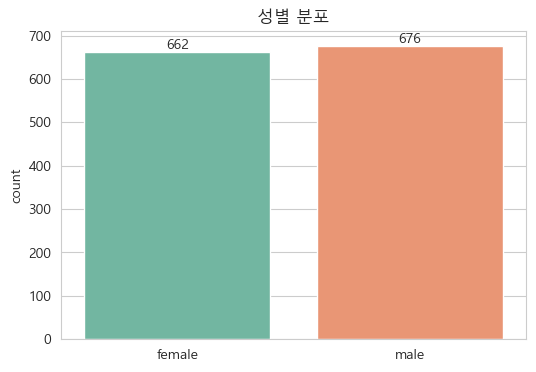

In [ ]:
# 성별 빈도 시각화
plt.figure(figsize=(6, 4))

# 왼쪽 — 성별 개수
g = sns.countplot(data=df, x='sex', palette='Set2')
g.set_title('성별 분포')
g.set_xlabel('')

# 막대 위에 개수 표기 (patches 활용)
for p in g.patches:
    g.text(p.get_x() + p.get_width()/2, p.get_height() + 8,
                 int(p.get_height()), ha='center')

plt.show()

# 해석: 성별은 거의 반반이다.

## 3-2. `region` 별 `charges` 분포

In [33]:
# 지역별 보험료 통계
region_stat = df.groupby('region')['charges'].agg(
    인원='size', 평균='mean', 중앙값='median', 표준편차='std').round(0)
region_stat

,인원,평균,중앙값,표준편차
region,,,,
northeast,324,13406.0,10058.0,11256.0
northwest,325,12418.0,8966.0,11072.0
southeast,364,14735.0,9294.0,13971.0
southwest,325,12347.0,8799.0,11557.0


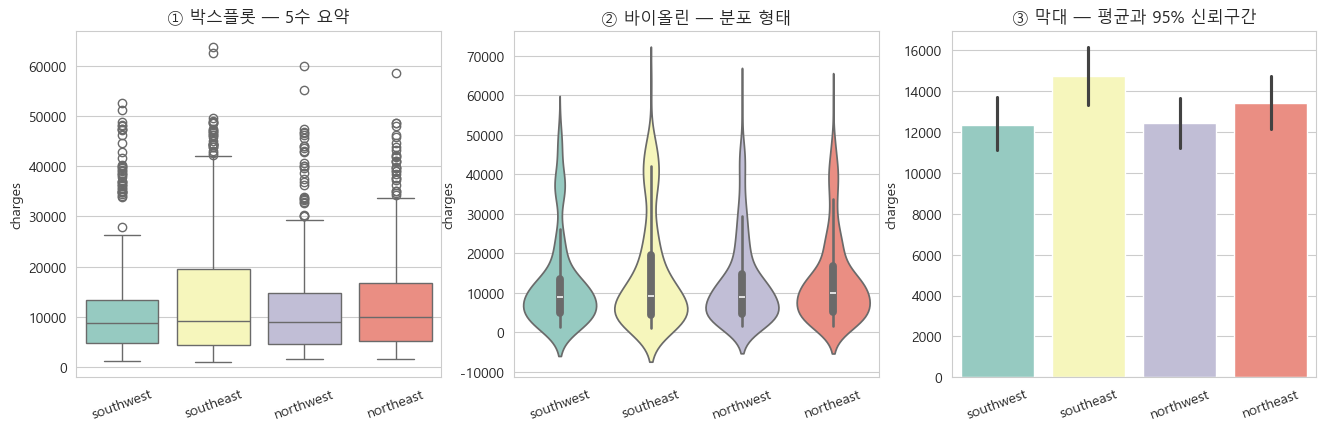

In [ ]:
# 지역별 charges 분포를 세 가지 방식으로 본다
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# 1. 박스플롯 — 5수 요약과 이상치
sns.boxplot(data=df, x='region', y='charges', ax=axes[0], palette='Set3')
axes[0].set_title('① 박스플롯 — 5수 요약')

# 2. 바이올린 — 분포의 형태까지
sns.violinplot(data=df, x='region', y='charges', ax=axes[1], palette='Set3')
axes[1].set_title('② 바이올린 — 분포 형태')

# 3. 막대 — 평균과 신뢰구간 (검은 선이 95% 신뢰구간)
sns.barplot(data=df, x='region', y='charges', ax=axes[2], palette='Set3')
axes[2].set_title('③ 막대 — 평균과 95% 신뢰구간')

for ax in axes:
    ax.set_xlabel('')
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=20)

plt.show()

In [36]:
# 지역 차이가 우연으로 볼 수 있는 수준인지 확인
# 4개 그룹의 평균 비교 → ANOVA
from scipy import stats

groups = [df[df['region'] == r]['charges'] for r in df['region'].unique()]
f_stat, p_val = stats.f_oneway(*groups)

print(f'ANOVA: F = {f_stat:.2f}, p = {p_val:.4f}')
print('→ 우연으로 보기 어렵다' if p_val < 0.05 else '→ 우연으로도 설명된다 (증거 부족)')
print()

# 최대·최소 지역의 차이가 실제로 얼마나 되는가
hi = region_stat['평균'].idxmax()
lo = region_stat['평균'].idxmin()
diff = region_stat.loc[hi, '평균'] - region_stat.loc[lo, '평균']
print(f'최고 {hi}: {region_stat.loc[hi, "평균"]:,.0f}')
print(f'최저 {lo}: {region_stat.loc[lo, "평균"]:,.0f}')
print(f'차이 {diff:,.0f}  (전체 평균의 {diff/df.charges.mean()*100:.0f}%)')

ANOVA: F = 2.97, p = 0.0309
→ 우연으로 보기 어렵다

최고 southeast: 14,735
최저 southwest: 12,347
차이 2,388  (전체 평균의 18%)


In [38]:
# 지역 차이의 정체를 확인 — 흡연율이 지역마다 다른가?
smoke_by_region = pd.crosstab(df['region'], df['smoker'], normalize='index') * 100
print('지역별 흡연율(%)')
print(smoke_by_region.round(1))
print()

# 흡연 여부를 통제하고 다시 지역을 비교
print('흡연 여부를 나눠서 본 지역별 평균 charges')
print(df.pivot_table(index='region', columns='smoker',
                     values='charges', aggfunc='mean').round(0))

지역별 흡연율(%)
smoker       no   yes
region               
northeast  79.3  20.7
northwest  82.2  17.8
southeast  75.0  25.0
southwest  82.2  17.8

흡연 여부를 나눠서 본 지역별 평균 charges
smoker         no      yes
region                    
northeast  9166.0  29674.0
northwest  8556.0  30192.0
southeast  8032.0  34845.0
southwest  8019.0  32269.0


### 해석 - 지역이 보험료에 미치는 영향

1. 지역 간의 차이는 있긴하지만 적음

    - 가장 높은 지역과 낮은 지역 평균의 차이는 전체 평균의 약 18%

2. 통계적으로 유의하나, 실무적 의미는 크지않음

    - 통계적으로 `p-value`가 0.03으로 유의한 차이가 있긴하지만, 차이 자체는 크지 않음

3. 그 차이도, 지역 때문이 아닌 흡연율 문제일 수 있음

    - southeast의 흡연 비율이 다른지역보다 높다

---

# 4. 수치형 데이터 분석

## 4-1. `age` 의 분포와 `charges` 와의 관계

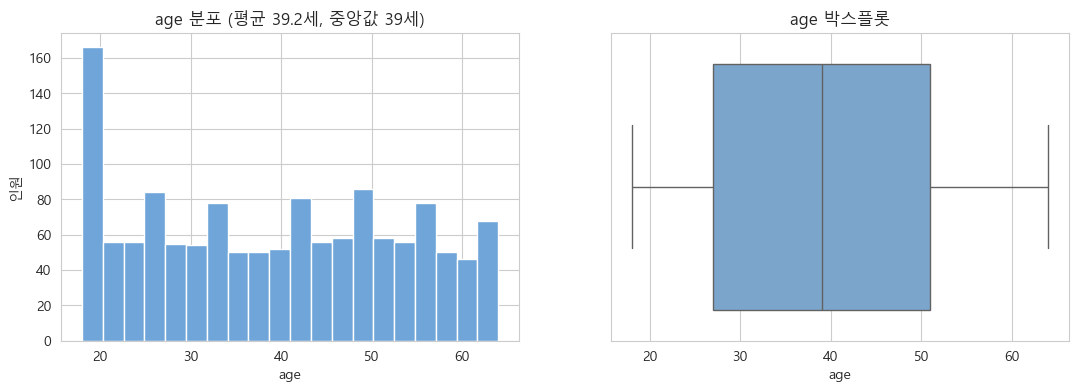

In [43]:
# age 분포 — 히스토그램과 박스플롯
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(df['age'], bins=20, color='#6fa5d8')
axes[0].set_title(f"age 분포 (평균 {df['age'].mean():.1f}세, 중앙값 {df['age'].median():.0f}세)")
axes[0].set_xlabel('age')
axes[0].set_ylabel('인원')

sns.boxplot(data=df, x='age', ax=axes[1], color='#6fa5d8')
axes[1].set_title('age 박스플롯')

plt.show()

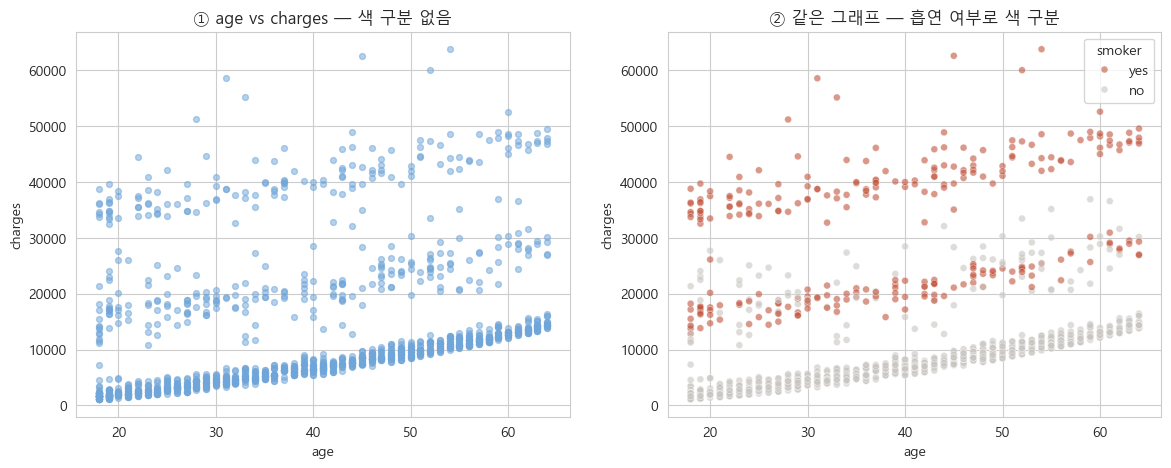

In [46]:
# 나이에 따른 charges 산점도 ★이 그래프가 이 데이터의 핵심
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 왼쪽 — 색 구분 없이
axes[0].scatter(df['age'], df['charges'], alpha=0.5, s=18, color='#6fa5d8')
axes[0].set_xlabel('age'); axes[0].set_ylabel('charges')
axes[0].set_title('① age vs charges — 색 구분 없음')

# 오른쪽 — 흡연 여부로 색을 나누면?
sns.scatterplot(data=df, x='age', y='charges', hue='smoker',
                alpha=0.6, s=25, ax=axes[1], palette={'no': '#c9c5c1', 'yes': '#c2543d'})
axes[1].set_title('② 같은 그래프 — 흡연 여부로 색 구분')

plt.show()

In [49]:
# 나이대별 평균 보험료 — 특정 나이대에서 높아지는지 확인. pd.cut(활용)
df['age_band'] = pd.cut(df['age'], bins=[17, 25, 35, 45, 55, 65],
                        labels=['18-25', '26-35', '36-45', '46-55', '56-64'])

age_stat = df.groupby('age_band')['charges'].agg(
    인원='size', 평균='mean', 중앙값='median').round(0)
print(age_stat)
print()

# 나이와 charges 의 상관계수 — 전체 / 흡연자 / 비흡연자
print(f"age ↔ charges 상관계수")
print(f" 전체     : {df['age'].corr(df['charges']):.3f}")
for s in ['no', 'yes']:
    sub = df[df['smoker'] == s]
    print(f" 흡연={s:<4}: {sub['age'].corr(sub['charges']):.3f} (n={len(sub)})")

           인원       평균      중앙값
age_band                       
18-25     306   9087.0   2636.0
26-35     268  10495.0   4901.0
36-45     264  13493.0   7443.0
46-55     284  15987.0  10478.0
56-64     216  18796.0  13430.0

age ↔ charges 상관계수
 전체     : 0.299
 흡연=no  : 0.628 (n=1064)
 흡연=yes : 0.368 (n=274)


### 해석 - 나이와 보험료

1. age 분포로 봤을 때 18~19세가 유독 많음.

- 가입 가능 최소 연령으로 인해 신규 가입이 몰렸을 가능성
- 그 외에는 균등함

2. **나이가 많을수록 보험료는 올라간다.**

- 나이대 별 평균이 계속 증가함

3. 산점도에 보이는 띠

- 전반적으로 보험료는 우상향
- 세 갈래로 갈라진 띠가 보여 흡연 여부를 추가했더니, 다음의 사항이 발견됨
    - **맨 아래 띠** — 비흡연자. 나이에 따라 완만히 상승
    - **위쪽 두 띠** — 흡연자. 훨씬 높은 위치에서 시작

## 4-2. `bmi` 의 분포와 `charges` 와의 관계

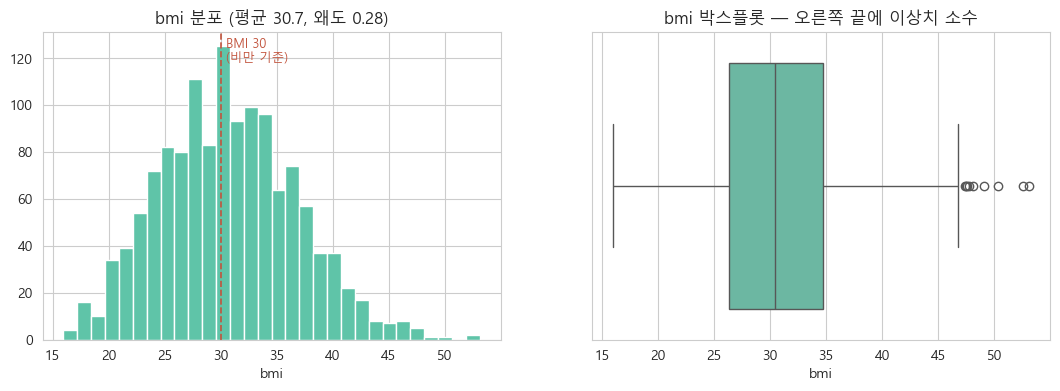

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(df['bmi'], bins=30, color='#5fc4a8')
# WHO 비만 기준 30 활용
axes[0].axvline(30, color='#c2543d', ls='--', lw=1.2)
axes[0].text(30.5, axes[0].get_ylim()[1]*0.9, 'BMI 30\n(비만 기준)',
             color='#c2543d', fontsize=9)
axes[0].set_title(f"bmi 분포 (평균 {df['bmi'].mean():.1f}, 왜도 {df['bmi'].skew():.2f})")
axes[0].set_xlabel('bmi')

sns.boxplot(data=df, x='bmi', ax=axes[1], color='#5fc4a8')
axes[1].set_title('bmi 박스플롯 — 오른쪽 끝에 이상치 소수')

plt.show()

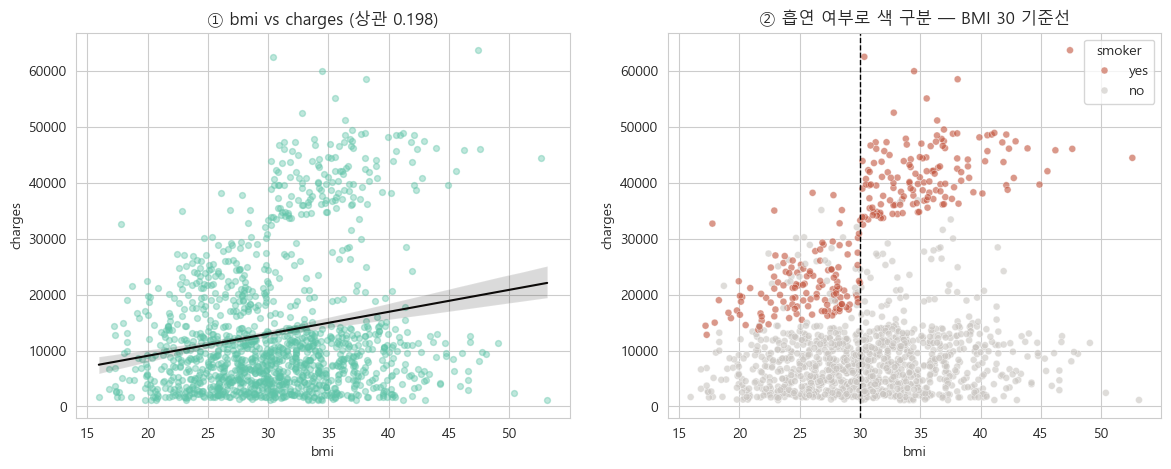

In [ ]:
# bmi 와 charges 의 관계
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 왼쪽 — 색 구분 없이 + 회귀선 (regplot 산점도 + 회귀선 그래프)
sns.regplot(data=df, x='bmi', y='charges', ax=axes[0],
            scatter_kws={'alpha': 0.4, 's': 18, 'color': '#5fc4a8'},
            line_kws={'color': '#0c0a09', 'lw': 1.5})
axes[0].set_title(f"① bmi vs charges (상관 {df['bmi'].corr(df['charges']):.3f})")

# 오른쪽 — 흡연 여부로 색 구분
sns.scatterplot(data=df, x='bmi', y='charges', hue='smoker',
                alpha=0.6, s=25, ax=axes[1],
                palette={'no': '#c9c5c1', 'yes': '#c2543d'})
axes[1].axvline(30, color='black', ls='--', lw=1)
axes[1].set_title('② 흡연 여부로 색 구분 — BMI 30 기준선')

plt.show()

In [56]:
# BMI 30 을 기준으로 비만 여부를 나누고, 흡연과 교차해서 본다
df['obese'] = (df['bmi'] >= 30).astype(int)

pivot = df.pivot_table(index='obese', columns='smoker',
                       values='charges', aggfunc='mean').round(0)
pivot.index = ['BMI < 30 (정상·과체중)', 'BMI >= 30 (비만)']
print('BMI x 흡연 별 평균 charges')
print(pivot)
print()

# 각 그룹에서 비만이 보험료를 얼마나 올리는지
for s in ['no', 'yes']:
    lo = df[(df.smoker == s) & (df.obese == 0)]['charges'].mean()
    hi = df[(df.smoker == s) & (df.obese == 1)]['charges'].mean()
    print(f'흡연={s:<4}  비만 시 +{hi-lo:,.0f}  ({hi/lo:.2f}배)')

BMI x 흡연 별 평균 charges
smoker                 no      yes
BMI < 30 (정상·과체중)  7977.0  21363.0
BMI >= 30 (비만)     8843.0  41558.0

흡연=no    비만 시 +866  (1.11배)
흡연=yes   비만 시 +20,195  (1.95배)


In [58]:
# 흡연 여부별로 bmi ↔ charges 상관계수를 따로 구한다
print('bmi ↔ charges 상관계수')
print(f" 전체     : {df['bmi'].corr(df['charges']):.3f}")
for s in ['no', 'yes']:
    sub = df[df['smoker'] == s]
    print(f" 흡연={s:<4}: {sub['bmi'].corr(sub['charges']):.3f} (n={len(sub)})")

bmi ↔ charges 상관계수
 전체     : 0.198
 흡연=no  : 0.084 (n=1064)
 흡연=yes : 0.806 (n=274)


### 해석 — BMI가 보험료에 미치는 영향

1. BMI의 분포 자체는 정규분포에 가까움

- 왜도가 0 근처에 평균이 30.7

2. 전체적으로 봤을 때 BMI와 보험료의 상관성은 약함.

- 점들이 크게 흩어져 있고, BMI는 보험료에 큰 영향을 끼치지 않는 것으로 보임

3. 하지만, 흡연 여부와 같이 확인했을 땐?

- BMI 30을 기준으로 흡연자들의 보험료가 위로 튀어오름
- 반면, 비흡연자는 BMI가 올라가도 보험료가 거의 올라가지 않음

| | BMI < 30 | BMI ≥ 30 | 증가폭 |
|---|---|---|---|
| **비흡연자** | 약 7,977 | 약 8,843 | **거의 없음** |
| **흡연자** | 약 21,363 | 약 41,558 | **약 2배** |

BMI와 흡연 여부는 **교호작용(interaction)**함

- 두 변수가 각각 더해지는 것이 아닌, 한 변수의 효과가 다른 변수의 값에 따라 달라지는 현상

> 3번 가설은 조건부로 일치.  
> BMI가 높아지면 보험료가 오르는게 아니라, 흡연자이면서 BMI가 높으면 보험료가 매우 높아진다.

---

# 5. 상관관계 분석

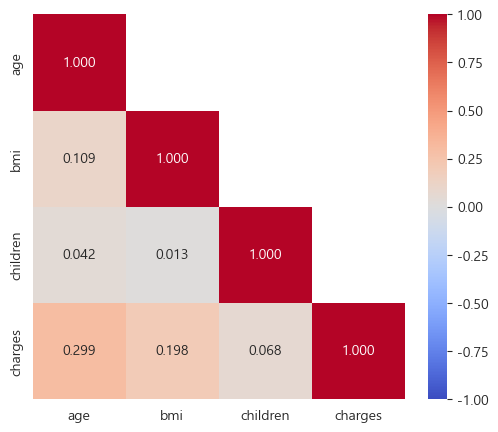

In [ ]:
# 수치형 변수들 간의 상관관계 히트맵
num_only = df[['age', 'bmi', 'children', 'charges']]
corr = num_only.corr()

# masking 처리
mask = np.zeros((4, 4))
for i, row in enumerate(mask):
    for j, v in enumerate(row):
        if i < j:
            mask[i, j] = 1

plt.figure(figsize=(6, 5))
plt.grid(False)

sns.heatmap(corr, annot=True, fmt='.3f', cmap='coolwarm',
            vmin=-1, vmax=1, # 범위 고정, 주석처리해서 차이 확인
            mask=mask)
ax.set_title('수치형 변수 상관관계 히트맵')
plt.show()

In [74]:
# charges 와의 상관계수만 뽑아 정렬
corr_charges = corr['charges'].drop('charges').sort_values(ascending=False)
print('charges 와의 상관계수 (수치형만)')
print(corr_charges.round(3))

charges 와의 상관계수 (수치형만)
age         0.299
bmi         0.198
children    0.068
Name: charges, dtype: float64


### 만약, 범주형 변수를 포함하면?

- 흡연 여부를 0과 1로
- 남성 여부를 0과 1로
- 비만 여부를 0과 1로 (BMI 30기준)

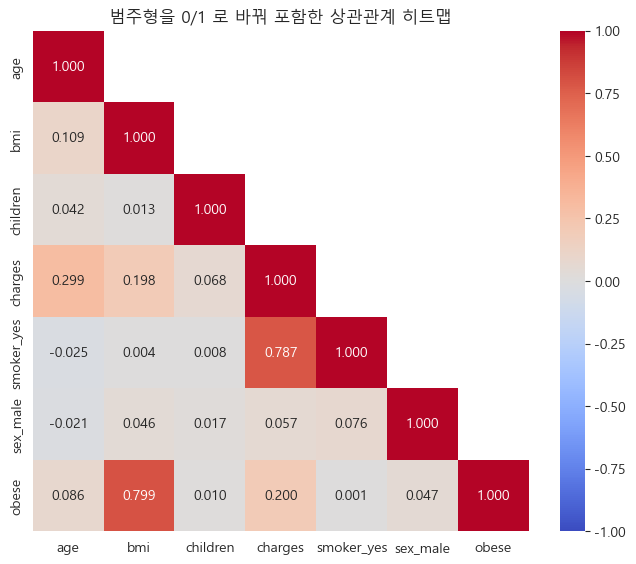

In [76]:
# 이진 범주형 변수를 0/1 로 변환해 상관관계에 포함시킨다
df_num = df[['age', 'bmi', 'children', 'charges']].copy()
df_num['smoker_yes'] = (df['smoker'] == 'yes').astype(int)   # 흡연=1
df_num['sex_male'] = (df['sex'] == 'male').astype(int)       # 남성=1
df_num['obese'] = (df['bmi'] >= 30).astype(int)              # 비만=1

corr_full = df_num.corr()

# masking 처리
mask = np.zeros((7, 7))
for i, row in enumerate(mask):
    for j, v in enumerate(row):
        if i < j:
            mask[i, j] = 1

plt.figure(figsize=(8, 6.5))
plt.grid(False)
g = sns.heatmap(corr_full, annot=True, fmt='.3f', cmap='coolwarm',
            vmin=-1, vmax=1, mask=mask)
g.set_title('범주형을 0/1 로 바꿔 포함한 상관관계 히트맵')
plt.show()

In [79]:
# charges 와의 상관계수를 다시 정렬
cc = corr_full['charges'].drop('charges').sort_values(key=abs, ascending=False)
print('charges 와의 상관계수 (범주형 포함)')
print(cc.round(3))

charges 와의 상관계수 (범주형 포함)
smoker_yes    0.787
age           0.299
obese         0.200
bmi           0.198
children      0.068
sex_male      0.057
Name: charges, dtype: float64


### 해석 — `charges` 와 상관성이 높은 변수

1. 수치형만 봤을 땐 `age`가 1위

- 하지만 0.3 정도로 강한 상관성을 띈다고 보기 어려움.

2. 범주형을 포함했을 땐, `흡연 여부`가 1위

- 약 0.79 정도로 매우 강한 상관관계를 띄고 있음 (나이의 2.6배 정도)

`df.corr()`는 범주형 변수는 제외하기 때문에, 범주형도 비교하고 싶다면 숫자로 변환 필요

- 만약 범주형이 이진형이 아닌 3개 이상의 값을 가진 경우에는 그룹화하여 평균 비교 해본다.

---

# 6. 데이터 시각화 - `smoker` x `sex` 별 `charges`

In [ ]:
# 흡연 여부와 성별의 조합별 평균 보험료
pivot_ss = df.pivot_table(index='smoker', columns='sex',
                          values='charges', aggfunc='mean').round(0)
print('흡연 x 성별 평균 charges')
print(pivot_ss)
print()

# 인원 수 확인 (표본 수 체크)
print('그룹별 인원')
print(pd.crosstab(df['smoker'], df['sex']))

흡연 × 성별 평균 charges
sex      female     male
smoker                  
no       8762.0   8087.0
yes     30679.0  33042.0

그룹별 인원
sex     female  male
smoker              
no         547   517
yes        115   159


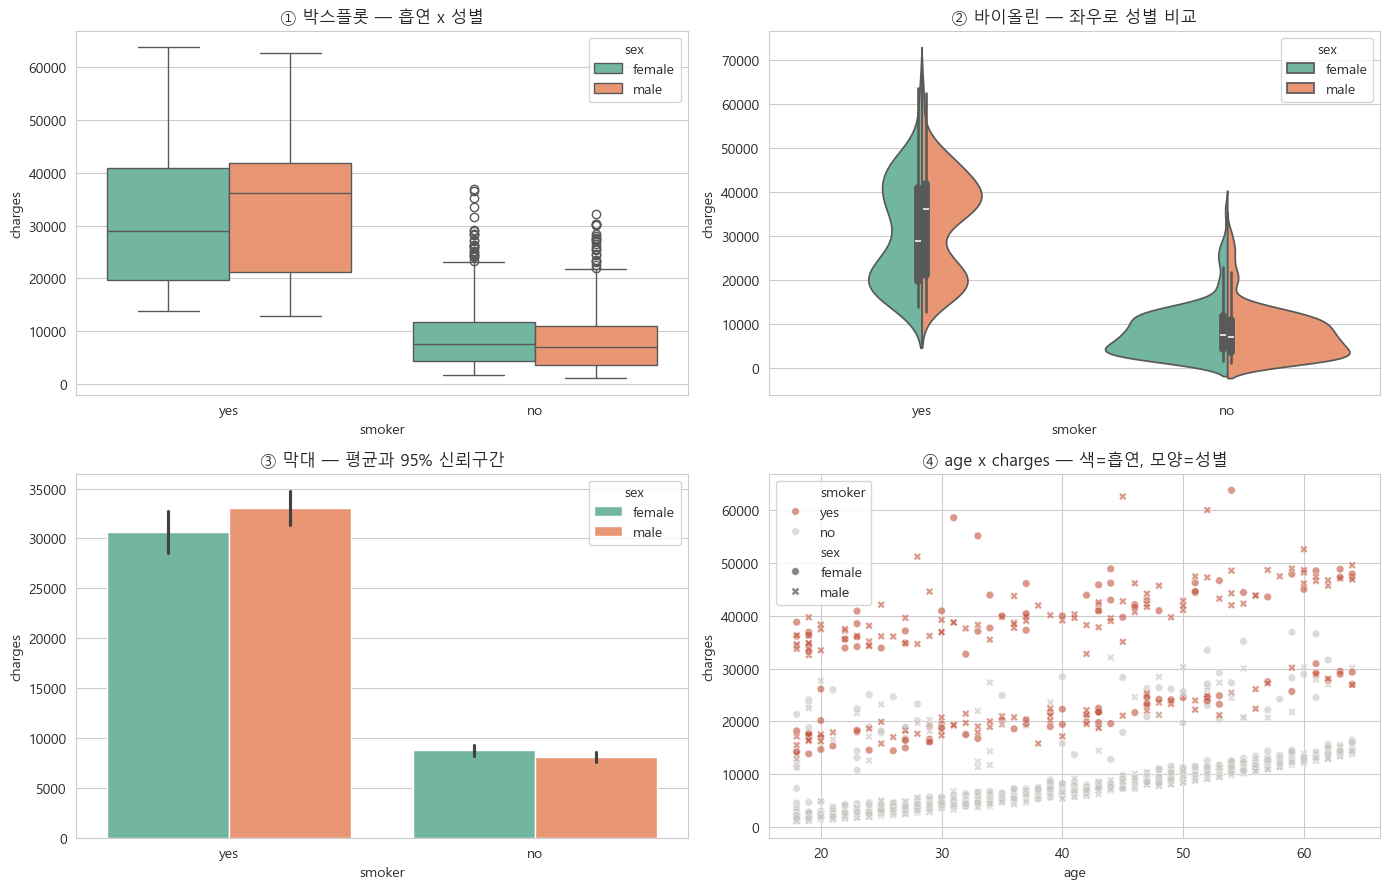

In [ ]:
# 네 가지 방식으로 시각화해 비교
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# ① 박스플롯 — 분포 전체
sns.boxplot(data=df, x='smoker', y='charges', hue='sex',
            ax=axes[0, 0], palette='Set2')
axes[0, 0].set_title('① 박스플롯 — 흡연 x 성별')

# ② 바이올린 — 분포 형태까지
sns.violinplot(data=df, x='smoker', y='charges', hue='sex',
               split=True, ax=axes[0, 1], palette='Set2')
axes[0, 1].set_title('② 바이올린 — 좌우로 성별 비교')

# ③ 막대 — 평균과 95% 신뢰구간
sns.barplot(data=df, x='smoker', y='charges', hue='sex',
            ax=axes[1, 0], palette='Set2')
axes[1, 0].set_title('③ 막대 — 평균과 95% 신뢰구간')

# ④ 산점도 — 나이까지 넣어 3개 변수를 한 번에
sns.scatterplot(data=df, x='age', y='charges', hue='smoker', style='sex',
                alpha=0.6, s=30, ax=axes[1, 1],
                palette={'no': '#c9c5c1', 'yes': '#c2543d'})
axes[1, 1].set_title('④ age x charges — 색=흡연, 모양=성별')

plt.tight_layout() # 레이아웃을 알맞게 변경 (주석 처리하여 비교)
plt.show()

In [93]:
# 흡연 효과와 성별 효과의 크기를 숫자로 비교
smoke_gap = df[df.smoker == 'yes']['charges'].mean() - df[df.smoker == 'no']['charges'].mean()
sex_gap = abs(df[df.sex == 'male']['charges'].mean() - df[df.sex == 'female']['charges'].mean())

print(f'흡연자 - 비흡연자 평균 차이 : {smoke_gap:>10,.0f}')
print(f'남성 - 여성 평균 차이       : {sex_gap:>10,.0f}')
print(f'→ 흡연 효과가 성별 효과의 {smoke_gap/sex_gap:.0f}배')
print()

# 흡연 여부를 통제하면 성별 차이가 남는가?
print('흡연 여부를 고정하고 본 성별 차이')
for s in ['no', 'yes']:
    sub = df[df.smoker == s]
    m = sub[sub.sex == 'male']['charges'].mean()
    f = sub[sub.sex == 'female']['charges'].mean()
    print(f' 흡연={s:<4}  남 {m:>9,.0f}  여 {f:>9,.0f}  차이 {m-f:>+9,.0f}')

흡연자 - 비흡연자 평균 차이 :     23,616
남성 - 여성 평균 차이       :      1,387
→ 흡연 효과가 성별 효과의 17배

흡연 여부를 고정하고 본 성별 차이
 흡연=no    남     8,087  여     8,762  차이      -675
 흡연=yes   남    33,042  여    30,679  차이    +2,363


In [95]:
# 성별 차이가 통계적으로 유의한지 확인 (흡연 여부를 나눠서)
for s in ['no', 'yes']:
    sub = df[df.smoker == s]
    m = sub[sub.sex == 'male']['charges']
    f = sub[sub.sex == 'female']['charges']
    t, p = stats.ttest_ind(m, f, equal_var=False)
    verdict = '유의미한 차이' if p < 0.05 else '차이가 유의미하지 않음'
    print(f'흡연={s:<4}  t = {t:>6.2f}, p = {p:.4f}  → {verdict}')

흡연=no    t =  -1.84, p = 0.0661  → 차이가 유의미하지 않음
흡연=yes   t =   1.66, p = 0.0979  → 차이가 유의미하지 않음


### 해석 - 흡연 여부와 성별이 보험료에 미치는 영향

1. 흡연의 영향은 가히 압도적

- 흡연자의 평균 보험료가 비흡연자보다 $23,000 비싸다.
- 박스플롯에서 두 상자는 거의 겹치지 않음

2. 성별의 영향은 미미함

- 비흡연자 집단에선 거의 차이가 없고,
- 흡연자 집단에선 조금 더 크지만 BMI의 차이일 가능성이 있음.

3. 흡연자 그룹안에서 분포가 쌍봉을 나타냄

- 바이올린 그래프에서 흡연자 쪽 봉우리가 2개 (BMI 30을 경계로 나뉜 것)

> 위 분석을 토대로 알 수 있는 세 집단의 특징
>
> | 집단 | 평균 보험료 | 비중 |
> |---|---|---|
> | 비흡연자 | 약 8,400 | 약 80% |
> | 흡연자 + BMI < 30 | 약 21,400 | 약 10% |
> | 흡연자 + BMI ≥ 30 | 약 41,600 | 약 10% |

**가설 H1(흡연 여부)은 강하게 성립, H6(성별)은 사실상 기각**

---

# 7. 결론 도출

## 7-1. 주요 인사이트 요약

In [ ]:
# 각 변수가 charges 를 얼마나 설명하는지 한 표로 정리
# 범주형은 그룹 평균의 차이, 수치형은 상관계수
rows = []

# 범주형 — 그룹 간 평균 차이 비율
for c in ['smoker', 'sex', 'region']:
    g = df.groupby(c)['charges'].mean()
    rows.append({'변수': c, '유형': '범주형',
                 '지표': '최대/최소 그룹 평균 비',
                 '값': round(g.max() / g.min(), 2)})

# 수치형 — charges 와의 상관계수
for c in ['age', 'bmi', 'children']:
    rows.append({'변수': c, '유형': '수치형',
                 '지표': 'charges 와의 상관계수',
                 '값': round(df[c].corr(df['charges']), 3)})

pd.DataFrame(rows).set_index('변수')

,유형,지표,값
변수,,,
smoker,범주형,최대/최소 그룹 평균 비,3.800
sex,범주형,최대/최소 그룹 평균 비,1.110
region,범주형,최대/최소 그룹 평균 비,1.190
age,수치형,charges 와의 상관계수,0.299
bmi,수치형,charges 와의 상관계수,0.198
children,수치형,charges 와의 상관계수,0.068


In [ ]:
# 가설 검증 결과 정리
# H1 흡연자의 보험료가 높다     - 성립 (약 3.8배)
# H2 나이가 많을수록 높다       - 약하게 성립 (상관 0.30) (비흡연자만 보면 더 강함)
# H3 BMI가 높을수록 높다       - 조건부 성립 - 흡연자에게만 나타남 (교호작용)
# H4 자녀가 많으면 높다         - 기각 - 상관 0.07, 거의 무관
# H5 지역에 따라 다르다         - 거의 기각 - 차이가 작고 흡연율 차이로 설명됨
# H6 성별에 따라 다르다         - 기각 - 흡연을 통제하면 차이가 거의 사라짐

## 7-2. 보험료 예측 모델 제안

In [97]:
# 모델에 쓸 변수를 실제로 만들어 본다
model_df = pd.DataFrame({
    'age': df['age'],
    'bmi': df['bmi'],
    'children': df['children'],
    'smoker': (df['smoker'] == 'yes').astype(int),        # 이진 인코딩
    'smoker_x_obese': ((df['smoker'] == 'yes') &
                       (df['bmi'] >= 30)).astype(int),     # ★교호작용 변수
    'charges': df['charges'],
})

# region 은 순서가 없는 3개 이상 범주 → 원-핫 인코딩
region_dummies = pd.get_dummies(df['region'], prefix='region', drop_first=True)
model_df = pd.concat([model_df, region_dummies], axis=1)

print('모델링용 데이터:', model_df.shape)
model_df.head()

모델링용 데이터: (1338, 9)


,age,bmi,children,smoker,smoker_x_obese,charges,region_northwest,region_southeast,region_southwest
0,19,27.900,0,1,0,16884.92400,False,False,True
1,18,33.770,1,0,0,1725.55230,False,True,False
2,28,33.000,3,0,0,4449.46200,False,True,False
3,33,22.705,0,0,0,21984.47061,True,False,False
4,32,28.880,0,0,0,3866.85520,True,False,False


In [ ]:
# 교호작용 변수를 넣는 것이 실제로 도움이 되는지 간단히 확인
# (numpy 최소제곱으로 선형회귀를 직접 계산)

def r_squared(X_cols):
    """주어진 변수들로 charges 를 설명했을 때의 R² 를 구한다"""
    X = model_df[X_cols].astype(float).values
    X = np.column_stack([np.ones(len(X)), X])      # 절편 항 추가
    y = model_df['charges'].values
    beta, *_ = np.linalg.lstsq(X, y, rcond=None)   # 최소제곱해
    pred = X @ beta
    ss_res = ((y - pred) ** 2).sum()
    ss_tot = ((y - y.mean()) ** 2).sum()
    return 1 - ss_res / ss_tot

print('설명력(R²) 비교 — 1에 가까울수록 잘 설명한다')
print('─' * 56)
print(f"1. age 만                       : {r_squared(['age']):.3f}")
print(f"2. age + bmi + children         : {r_squared(['age','bmi','children']):.3f}")
print(f"3. 2 + smoker                   : {r_squared(['age','bmi','children','smoker']):.3f}")
print(f"4. 3 + 교호작용(smoker×비만)      : "
      f"{r_squared(['age','bmi','children','smoker','smoker_x_obese']):.3f}")

설명력(R²) 비교 — 1에 가까울수록 잘 설명한다
────────────────────────────────────────────────────────
1. age 만                       : 0.089
2. age + bmi + children         : 0.120
3. 2 + smoker                   : 0.750
4. 3 + 교호작용(smoker×비만)      : 0.862


### 제안 모델

```python
charges ≈ b0
        + b1 · age                    # 나이 — 완만한 상승
        + b2 · bmi                    # 체질량지수
        + b3 · children               # 부양 자녀 수
        + b4 · smoker                 # 흡연 여부 (0/1)  ★주 변수
        + b5 · (smoker × BMI≥30)      # 교호작용 항      ★핵심
```